# Geovisor - Hospitales y Clinicas ITT

**Proyecto:** Gobierno de Datos 2026

**Repositorio:** [GitHub](https://github.com/j0rg3c45/Hospitales_Cl-nicas_ITT.git)


---
## 1. Dependencias


In [29]:
%pip install folium matplotlib --quiet


---
## 2. Librerias


In [30]:
import json, os
import folium
from folium import FeatureGroup, LayerControl, GeoJson
from folium.plugins import MiniMap, Fullscreen, LocateControl
from IPython.display import display
import matplotlib.pyplot as plt
from collections import Counter
print('Librerias importadas.')


Librerias importadas.


---
## 3. Carga de Datos


In [31]:
if not os.path.exists('Hospitales_Cl-nicas_ITT'):
    !git clone https://github.com/j0rg3c45/Hospitales_Cl-nicas_ITT.git

DATA_PATH = 'Hospitales_Cl-nicas_ITT/Data/centros_medicos_completo.json'
if not os.path.exists(DATA_PATH):
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    centros = json.load(f)
print(f'Centros cargados: {len(centros)}')


Centros cargados: 43


---
## 4. Tabla Resumen


In [32]:
header = f"{'#':<3} {'Nombre':<40} {'ESE':<18} {'Comuna':<12} {'Estado':<15} {'Usuarios':>10} {'Monto':>15}"
print(header)
print('-' * len(header))
for i, c in enumerate(centros):
    monto_str = f"${c['monto']:,.0f}" if c['monto'] > 0 else 'Pendiente'
    print(f"{i+1:<3} {c['nombre'][:39]:<40} {c['ese'][:17]:<18} {c['comuna'][:11]:<12} {c['estado'][:14]:<15} {c['usuarios']:>10,} {monto_str:>15}")


#   Nombre                                   ESE                Comuna       Estado            Usuarios           Monto
-----------------------------------------------------------------------------------------------------------------------
1   IPS - UNION DE VIVIENDA POPULAR          ESE Suroriente     COMUNA 16    Finalizado           4,807    $101,550,860
2   IPS - POLVORINES                         ESE Ladera         COMUNA 18    Finalizado           2,851    $490,729,810
3   IPS - PETECUY III                        ESE Norte          COMUNA 06    Finalizado          10,750    $496,980,692
4   IPS - CHARCO AZUL                        ESE Oriente        COMUNA 13    Finalizado           8,300    $706,747,012
5   IPS - CIUDAD CORDOBA                     ESE Oriente        COMUNA 15    Finalizado           7,000    $705,590,738
6   IPS - FRAY DAMIAN                        ESE Ladera         COMUNA 03    Finalizado          11,089    $184,239,319
7   IPS - POPULAR                       

---
## 5. Analisis Grafico


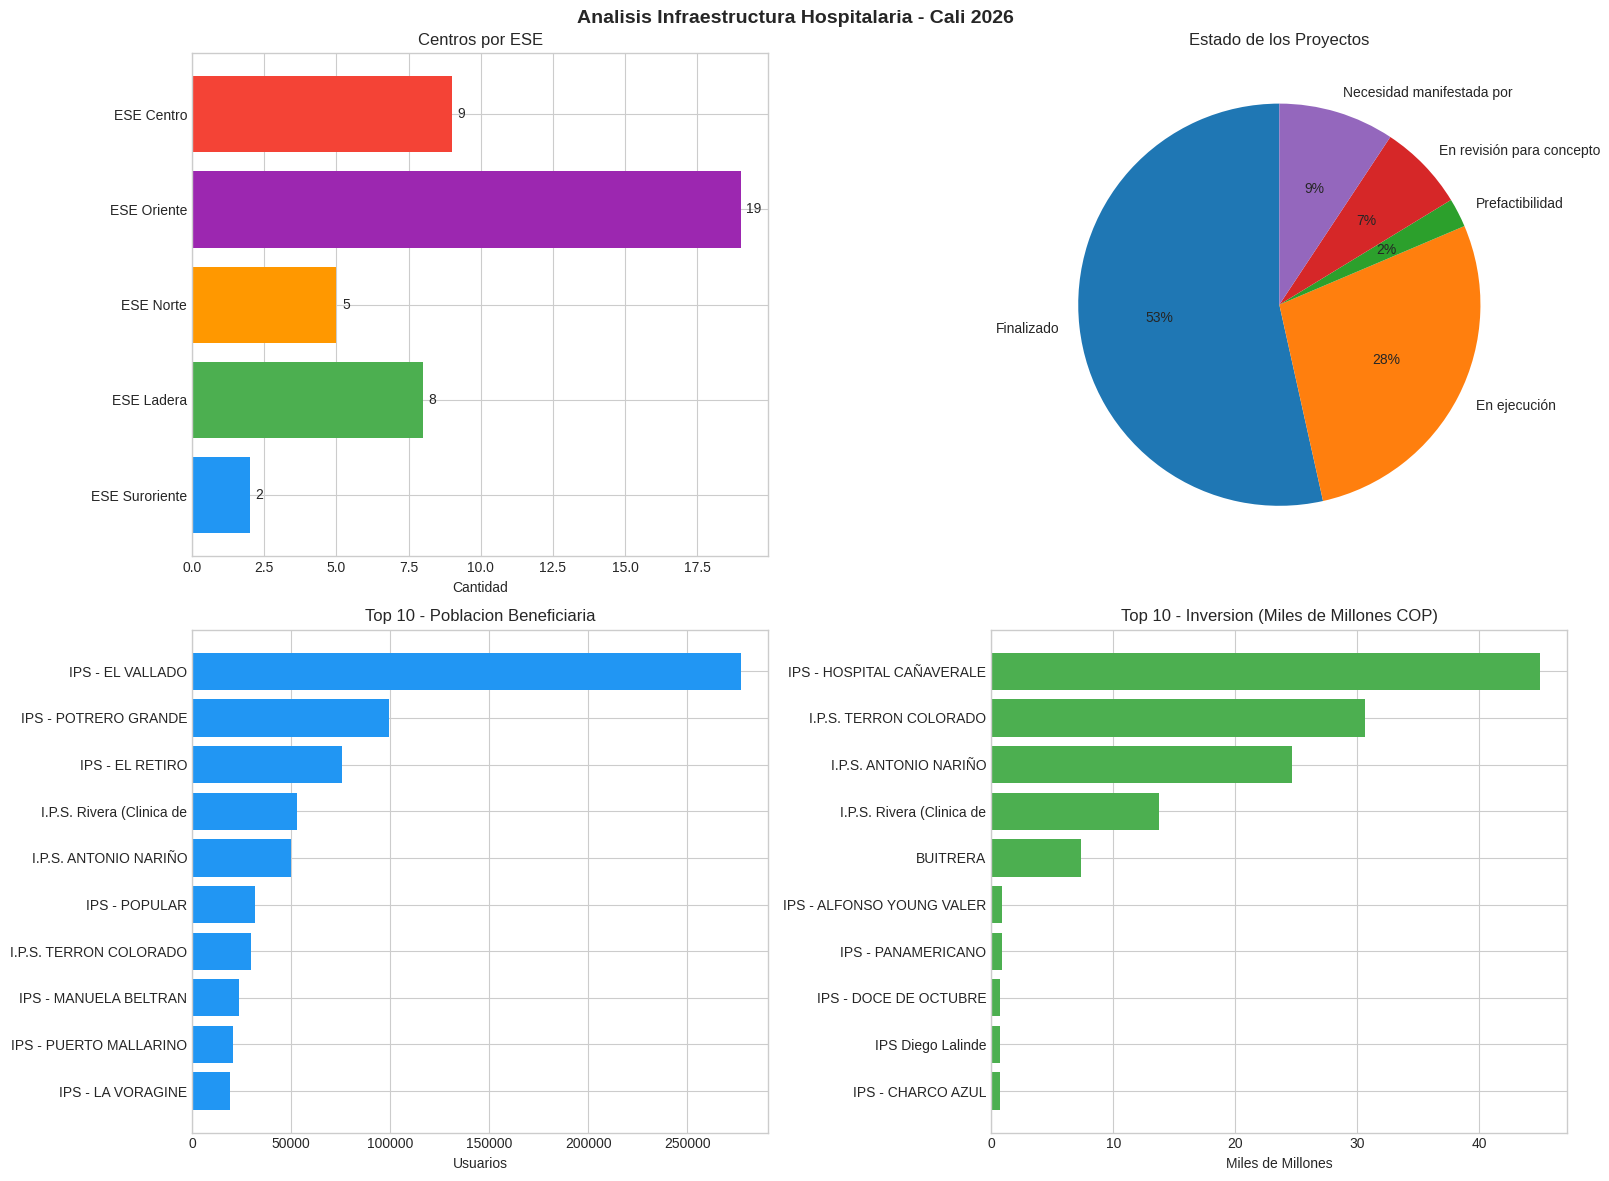

In [33]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Infraestructura Hospitalaria - Cali 2026', fontsize=14, fontweight='bold')

# 1: Por ESE
eses = Counter(c['ese'] for c in centros)
ax1 = axes[0, 0]
bars = ax1.barh(list(eses.keys()), list(eses.values()), color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'])
ax1.set_title('Centros por ESE')
ax1.set_xlabel('Cantidad')
for bar in bars:
    ax1.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2, f'{int(bar.get_width())}', va='center')

# 2: Por Estado
estados = Counter(c['estado'] for c in centros)
ax2 = axes[0, 1]
labels_estado = [k[:25] for k in estados.keys()]
ax2.pie(estados.values(), labels=labels_estado, autopct='%1.0f%%', startangle=90)
ax2.set_title('Estado de los Proyectos')

# 3: Top 10 usuarios
top_u = sorted(centros, key=lambda x: x['usuarios'], reverse=True)[:10]
ax3 = axes[1, 0]
ax3.barh([c['nombre'][:25] for c in top_u][::-1], [c['usuarios'] for c in top_u][::-1], color='#2196F3')
ax3.set_title('Top 10 - Poblacion Beneficiaria')
ax3.set_xlabel('Usuarios')

# 4: Top 10 inversion
top_m = sorted([c for c in centros if c['monto']>0], key=lambda x: x['monto'], reverse=True)[:10]
ax4 = axes[1, 1]
ax4.barh([c['nombre'][:25] for c in top_m][::-1], [c['monto']/1e9 for c in top_m][::-1], color='#4CAF50')
ax4.set_title('Top 10 - Inversion (Miles de Millones COP)')
ax4.set_xlabel('Miles de Millones')

plt.tight_layout()
plt.show()


In [34]:
total_usuarios = sum(c['usuarios'] for c in centros)
total_inv = sum(c['monto'] for c in centros if c['monto']>0)
fin = sum(1 for c in centros if c['estado']=='Finalizado')
ej = sum(1 for c in centros if 'ejecuci' in c['estado'].lower())
print('RESUMEN GENERAL')
print('='*50)
print(f'Total centros:          {len(centros)}')
print(f'Finalizados:            {fin}')
print(f'En ejecucion:           {ej}')
print(f'Otros:                  {len(centros)-fin-ej}')
print(f'Poblacion total:        {total_usuarios:,}')
print(f'Inversion total:        ${total_inv:,.0f}')


RESUMEN GENERAL
Total centros:          43
Finalizados:            23
En ejecucion:           12
Otros:                  8
Poblacion total:        954,145
Inversion total:        $140,653,837,895


---
## 6. Espacializacion / Geovisor

Colores:
- Verde = Finalizado
- Naranja = En ejecucion
- Azul = En revision
- Rojo = Pendiente/Necesidad
- **Morado (estrella) = Puntos de estudio principales**
- **Poligonos rojos = Terrenos de los puntos de estudio**


In [35]:
# --- PUNTOS DE ESTUDIO (3 principales) ---
puntos_estudio = [
    {'nombre': 'I.P.S. TERRON COLORADO', 'lat': 3.4525133, 'lon': -76.5594922},
    {'nombre': 'I.P.S. Rivera (Clinica de Mama)', 'lat': 3.4741476, 'lon': -76.4905206},
    {'nombre': 'I.P.S. ANTONIO NARINO', 'lat': 3.4161563, 'lon': -76.5083629}
]

# Poligonos de terrenos (EPSG:4326)
poligonos = [
    {'nombre': 'Terreno La Rivera - Comuna 05',
     'coords': [[3.4740086,-76.4902269],[3.4738546,-76.4907211],[3.4751942,-76.4911306],
       [3.4754007,-76.4902942],[3.4754079,-76.4902657],[3.4754107,-76.4902446],
       [3.4754059,-76.4902093],[3.4753945,-76.4901825],[3.4753789,-76.4901621],
       [3.4753648,-76.4901466],[3.4753463,-76.490128],[3.4753252,-76.4901113],
       [3.4752917,-76.4900927],[3.4752423,-76.4900744],[3.4751737,-76.4900498],
       [3.4750354,-76.4900015],[3.4746139,-76.4898702],[3.4741893,-76.489738],
       [3.474179,-76.4897356],[3.4741701,-76.4897351],[3.4741618,-76.489738],
       [3.4741568,-76.4897475],[3.474153,-76.4897619],[3.4741441,-76.489792],
       [3.4740086,-76.4902269]]},
    {'nombre': 'Terreno Antonio Narino - Comuna 16',
     'coords': [[3.4165601,-76.5092721],[3.4171388,-76.5086692],
       [3.4158096,-76.5074186],[3.415249,-76.5080124],[3.4165601,-76.5092721]]}
]

# Centro del mapa en los 3 puntos de estudio
center_lat = sum(p['lat'] for p in puntos_estudio) / len(puntos_estudio)
center_lon = sum(p['lon'] for p in puntos_estudio) / len(puntos_estudio)

# Tiles
GOOGLE_SAT = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}'
GOOGLE_HYB = 'https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}'
GOOGLE_MAP = 'https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}'

mapa = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None, control_scale=True)
folium.TileLayer(tiles=GOOGLE_SAT, attr='Google', name='Google Satellite', overlay=False).add_to(mapa)
folium.TileLayer(tiles=GOOGLE_HYB, attr='Google', name='Google Hybrid', overlay=False).add_to(mapa)
folium.TileLayer(tiles=GOOGLE_MAP, attr='Google', name='Google Maps', overlay=False).add_to(mapa)
folium.TileLayer(tiles='OpenStreetMap', name='OpenStreetMap', overlay=False).add_to(mapa)

# --- COLOR POR ESTADO ---
def color_estado(estado):
    if estado == 'Finalizado': return 'green'
    elif 'ejecuci' in estado.lower(): return 'orange'
    elif 'revision' in estado.lower() or 'alistamiento' in estado.lower(): return 'blue'
    return 'red'

# --- CAPA: Todos los centros agrupados por ESE ---
eses_unicas = sorted(set(c['ese'] for c in centros))
nombres_estudio = [p['nombre'] for p in puntos_estudio]

for ese in eses_unicas:
    fg = FeatureGroup(name=ese, show=True)
    for c in [x for x in centros if x['ese'] == ese]:
        # Saltar los 3 de estudio (se agregan aparte)
        if c['nombre'] in nombres_estudio:
            continue
        color = color_estado(c['estado'])
        monto_str = f"${c['monto']:,.0f}" if c['monto']>0 else 'Pendiente'
        popup = (f"<div style='font-family:Arial;font-size:11px;min-width:250px;max-height:300px;overflow-y:auto;'>"
                 f"<b>{c['nombre']}</b><hr>"
                 f"<b>ESE:</b> {c['ese']}<br><b>Tipo:</b> {c['tipo_ips']}<br>"
                 f"<b>Dir:</b> {c['direccion']}<br><b>Comuna:</b> {c['comuna']}<br>"
                 f"<b>Usuarios:</b> {c['usuarios']:,}<br>"
                 f"<b>Amb. actuales:</b> {c['ambientes_actuales']}<br>"
                 f"<b>Amb. proyectados:</b> {c['ambientes_proyectados']}<br>"
                 f"<b>Servicios:</b> {c['servicios_actuales']}<br>"
                 f"<b>Nuevos:</b> {c['servicios_nuevos']}<br>"
                 f"<b>Estado:</b> {c['estado']}<br><b>Monto:</b> {monto_str}</div>")
        folium.Marker(
            location=[c['lat'], c['lon']],
            popup=folium.Popup(popup, max_width=320),
            tooltip=f"{c['nombre']} ({c['estado']})",
            icon=folium.Icon(color=color, icon='plus-sign', prefix='glyphicon')
        ).add_to(fg)
    fg.add_to(mapa)

# --- CAPA: Puntos de estudio (diferenciados) ---
fg_estudio = FeatureGroup(name='PUNTOS DE ESTUDIO', show=True)
for c in centros:
    if c['nombre'] in nombres_estudio:
        monto_str = f"${c['monto']:,.0f}" if c['monto']>0 else 'Pendiente'
        popup = (f"<div style='font-family:Arial;font-size:11px;min-width:280px;max-height:350px;overflow-y:auto;'>"
                 f"<h4 style='color:#6A1B9A;'>{c['nombre']}</h4><hr>"
                 f"<b>ESE:</b> {c['ese']}<br><b>Tipo:</b> {c['tipo_ips']}<br>"
                 f"<b>Dir:</b> {c['direccion']}<br><b>Comuna:</b> {c['comuna']}<br>"
                 f"<b>Usuarios:</b> {c['usuarios']:,}<br>"
                 f"<b>Amb. actuales:</b> {c['ambientes_actuales']}<br>"
                 f"<b>Amb. proyectados:</b> {c['ambientes_proyectados']}<br>"
                 f"<b>Servicios:</b> {c['servicios_actuales']}<br>"
                 f"<b>Nuevos:</b> {c['servicios_nuevos']}<br>"
                 f"<b>Estado:</b> {c['estado']}<br><b>Monto:</b> {monto_str}<br>"
                 f"<b>Inicio:</b> {c['fecha_inicio']}<br><b>Fin:</b> {c['fecha_fin']}</div>")
        folium.Marker(
            location=[c['lat'], c['lon']],
            popup=folium.Popup(popup, max_width=350),
            tooltip=f"[ESTUDIO] {c['nombre']}",
            icon=folium.Icon(color='purple', icon='star', prefix='glyphicon')
        ).add_to(fg_estudio)
fg_estudio.add_to(mapa)

# --- CAPA: Poligonos de terrenos ---
fg_poly = FeatureGroup(name='TERRENOS (Poligonos)', show=True)
for poly in poligonos:
    geojson_coords = [[coord[1], coord[0]] for coord in poly['coords']]
    feat = {'type':'Feature','properties':{'nombre':poly['nombre']},'geometry':{'type':'Polygon','coordinates':[geojson_coords]}}
    GeoJson(feat, style_function=lambda x: {'color':'red','weight':2,'fillOpacity':0,'fillColor':'transparent'}, tooltip=poly['nombre']).add_to(fg_poly)
fg_poly.add_to(mapa)

# --- Controles ---
LayerControl(collapsed=False, position='topright').add_to(mapa)
MiniMap(toggle_display=True, position='bottomleft').add_to(mapa)
Fullscreen(position='topleft').add_to(mapa)
LocateControl(strings={'title':'Mi ubicacion'}).add_to(mapa)

print(f'Geovisor: {len(centros)} centros + {len(poligonos)} terrenos.')
print(f'Centro del mapa en los 3 puntos de estudio: [{center_lat:.4f}, {center_lon:.4f}]')


Geovisor: 43 centros + 2 terrenos.
Centro del mapa en los 3 puntos de estudio: [3.4476, -76.5195]


---
## 7. Visualizacion del Geovisor


In [38]:
display(mapa)


---
## 8. Exportacion


In [37]:
OUTPUT = 'geovisor_hospitales_clinicas_ITT.html'
mapa.save(OUTPUT)
print(f'Exportado: {OUTPUT}')
try:
    from google.colab import files
    files.download(OUTPUT)
except:
    print('Abra el archivo desde el explorador.')


Exportado: geovisor_hospitales_clinicas_ITT.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>